In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline


In [13]:
df = pd.read_csv("UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [14]:
df.shape

(30000, 25)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [16]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [17]:
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)

In [18]:
df.isnull().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

In [19]:
df['default'].value_counts()

default
0    23364
1     6636
Name: count, dtype: int64

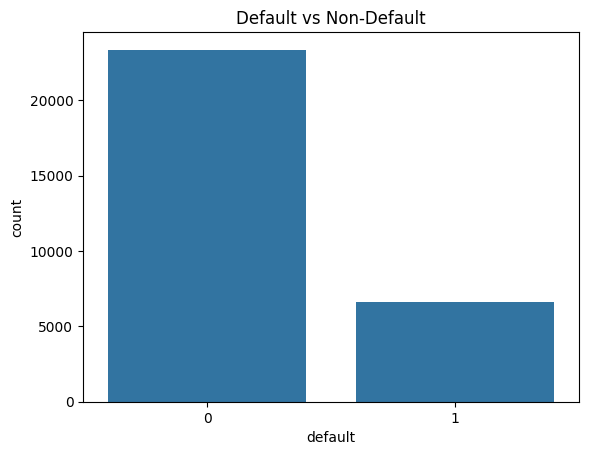

In [20]:
sns.countplot(x='default', data=df)
plt.title("Default vs Non-Default")
plt.show()

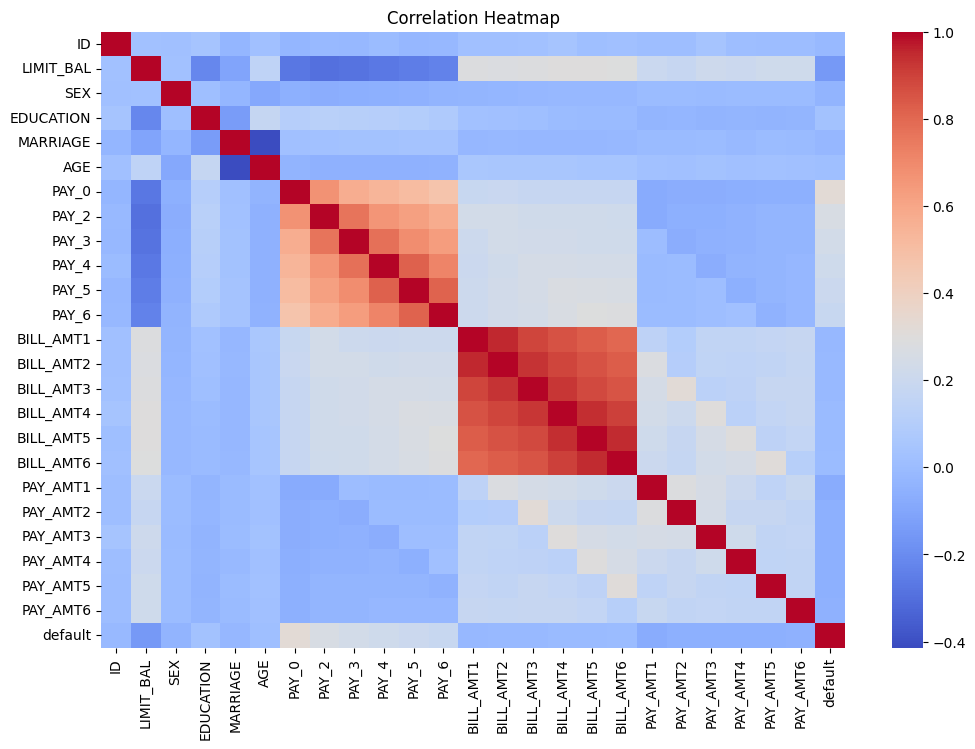

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

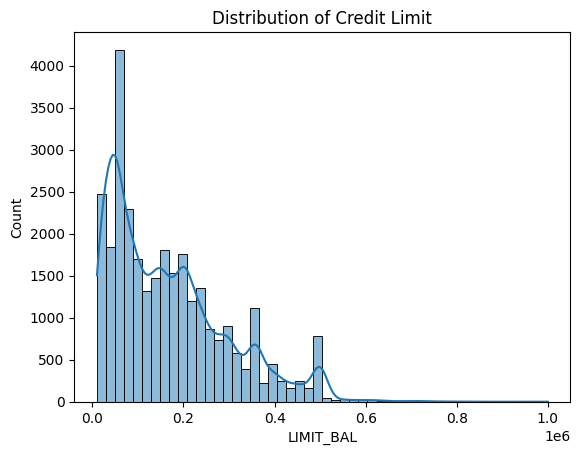

In [22]:
sns.histplot(df['LIMIT_BAL'], bins=50, kde=True)
plt.title("Distribution of Credit Limit")
plt.show()

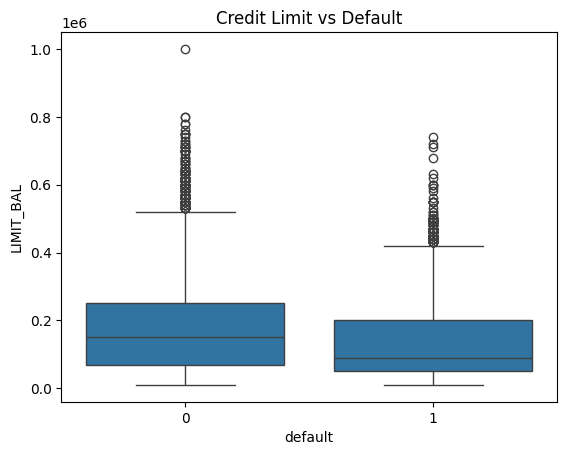

In [23]:
sns.boxplot(x='default', y='LIMIT_BAL', data=df)
plt.title("Credit Limit vs Default")
plt.show()

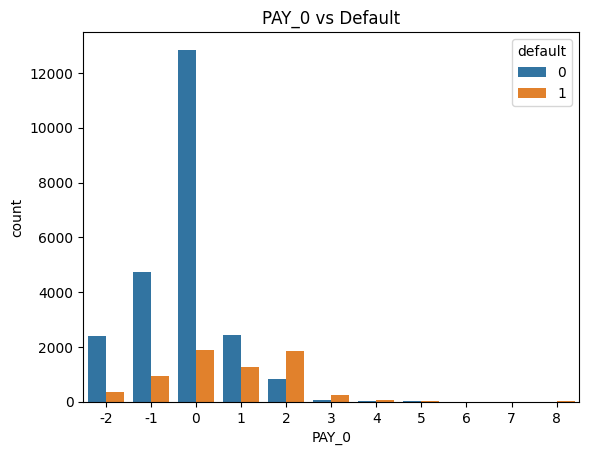

In [24]:
sns.countplot(x='PAY_0', hue='default', data=df)
plt.title("PAY_0 vs Default")
plt.show()

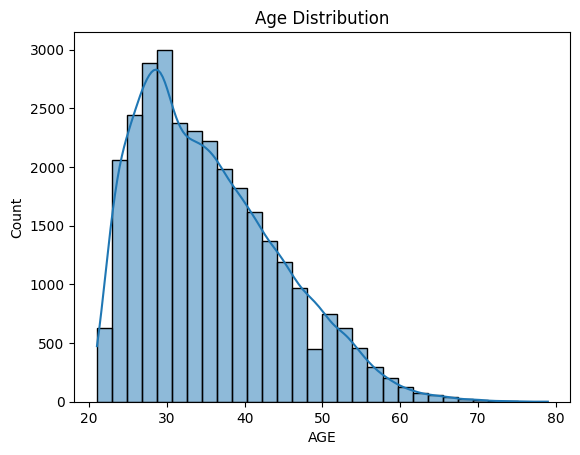

In [25]:
sns.histplot(df['AGE'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

In [26]:
corr_target = df.corr()['default'].sort_values(ascending=False)
print(corr_target)

default      1.000000
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
EDUCATION    0.028006
AGE          0.013890
BILL_AMT6   -0.005372
BILL_AMT5   -0.006760
BILL_AMT4   -0.010156
ID          -0.013952
BILL_AMT3   -0.014076
BILL_AMT2   -0.014193
BILL_AMT1   -0.019644
MARRIAGE    -0.024339
SEX         -0.039961
PAY_AMT6    -0.053183
PAY_AMT5    -0.055124
PAY_AMT3    -0.056250
PAY_AMT4    -0.056827
PAY_AMT2    -0.058579
PAY_AMT1    -0.072929
LIMIT_BAL   -0.153520
Name: default, dtype: float64


In [28]:
X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
X_train = X_train.drop('ID', axis=1)
X_test = X_test.drop('ID', axis=1)

In [30]:
X_train = pd.get_dummies(X_train, columns=['SEX','EDUCATION','MARRIAGE'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['SEX','EDUCATION','MARRIAGE'], drop_first=True)

# Align columns (VERY IMPORTANT)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(24000, 30)
(6000, 30)


In [36]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

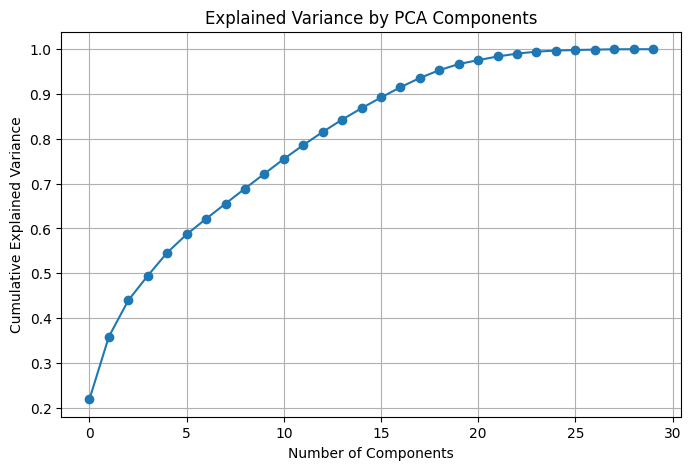

In [37]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid()
plt.show()

In [38]:
pca = PCA(n_components=0.95)  # keep 95% variance

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original shape:", X_train_scaled.shape)
print("Reduced shape:", X_train_pca.shape)

Original shape: (24000, 30)
Reduced shape: (24000, 19)


In [41]:
svm_model = SVC(kernel='rbf', random_state=42)

svm_model.fit(X_train_pca, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [42]:
y_pred = svm_model.predict(X_test_pca)

In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8038333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.95      0.88      4673
           1       0.62      0.30      0.40      1327

    accuracy                           0.80      6000
   macro avg       0.72      0.62      0.64      6000
weighted avg       0.78      0.80      0.78      6000



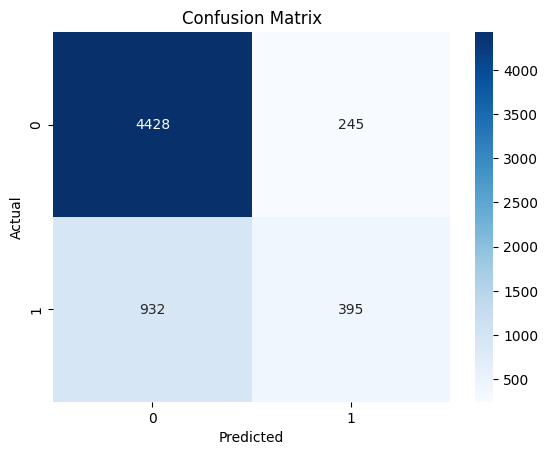

In [45]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [47]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid.fit(X_train_pca, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}


In [48]:
best_svm = grid.best_estimator_

y_pred_best = best_svm.predict(X_test_pca)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))

Tuned Accuracy: 0.8043333333333333


              precision    recall  f1-score   support

           0       0.82      0.95      0.88      4673
           1       0.63      0.28      0.39      1327

    accuracy                           0.80      6000
   macro avg       0.73      0.62      0.64      6000
weighted avg       0.78      0.80      0.77      6000



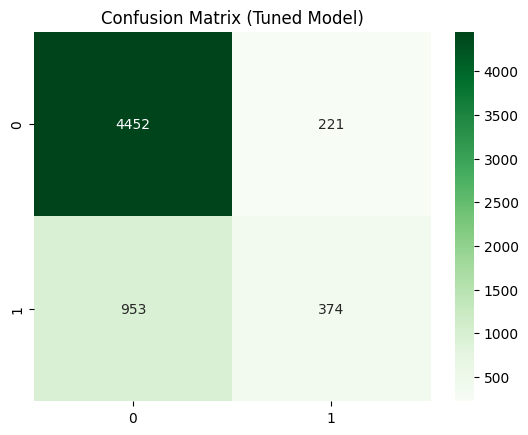

In [49]:
print(classification_report(y_test, y_pred_best))

sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (Tuned Model)")
plt.show()

In [52]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('svm', SVC(kernel='rbf'))
])

pipeline.fit(X_train, y_train)

y_pred_pipeline = pipeline.predict(X_test)

In [53]:
print("Pipeline Accuracy:", accuracy_score(y_test, y_pred_pipeline))
print(classification_report(y_test, y_pred_pipeline))

Pipeline Accuracy: 0.8038333333333333
              precision    recall  f1-score   support

           0       0.83      0.95      0.88      4673
           1       0.62      0.30      0.40      1327

    accuracy                           0.80      6000
   macro avg       0.72      0.62      0.64      6000
weighted avg       0.78      0.80      0.78      6000



In [54]:
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.01, 0.001]
}

grid_pipeline = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_pipeline.fit(X_train, y_train)

print("Best Params:", grid_pipeline.best_params_)

best_model = grid_pipeline.best_estimator_

Best Params: {'svm__C': 1, 'svm__gamma': 0.01}


In [55]:
y_final = best_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_final))
print(classification_report(y_test, y_final))

Final Accuracy: 0.8043333333333333
              precision    recall  f1-score   support

           0       0.82      0.95      0.88      4673
           1       0.63      0.28      0.39      1327

    accuracy                           0.80      6000
   macro avg       0.73      0.62      0.64      6000
weighted avg       0.78      0.80      0.77      6000

